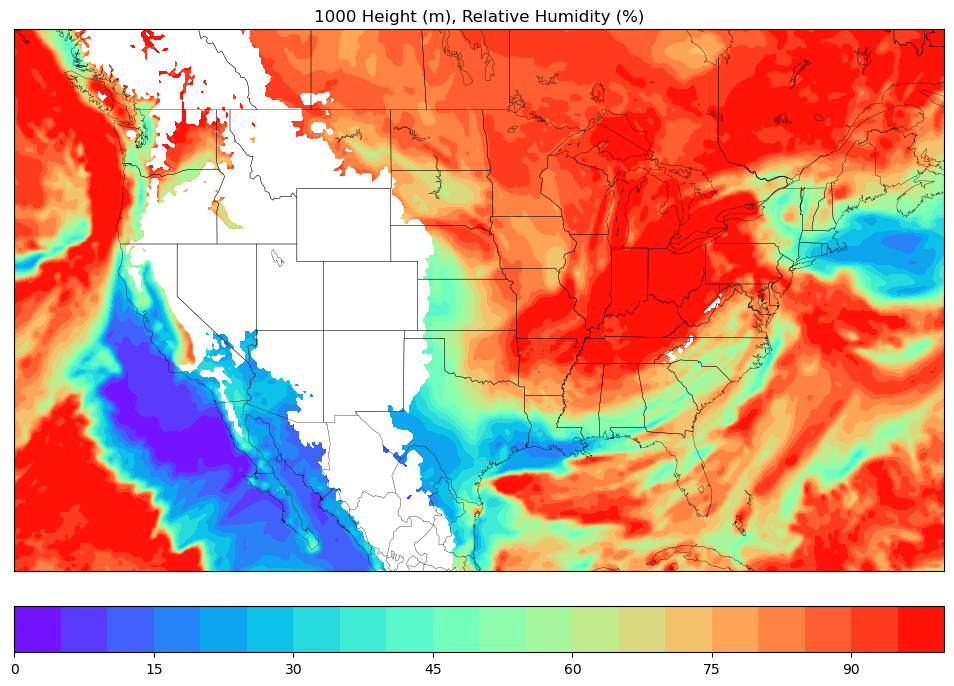

In [1]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import get_cmap

from wrf import getvar, interplevel, to_np, get_basemap, latlon_coords

# Open the NetCDF file
#ncfile = Dataset("wrfout_d01_2025-01-02_00:00:00")
#ncfile = Dataset("../WRFOUT/wrfout_d01_2025-01-01_23:00:00")
ncfile = Dataset(" /data/wto/WRFOUT/run_CONUS_20250214/wrfout_d01_2025-01-01_00:00:00")
#ncfile = Dataset(" /home/wto/Models/WRF_TUTORIAL/WRFV4.5/test/em_real/wrfout_d01_2025-01-01_03:00:00")
#ncfile = Dataset("/home/wto/Models/WRF_TUTORIAL/WRFV4.5/test/em_real/wrfout_d02_2025-01-01_00:00:00")

# Extract the pressure, geopotential height, and wind variables
#p = getvar(ncfile, "pressure")
z = getvar(ncfile, "z", units="m")
#ua = getvar(ncfile, "ua", units="kt")
#va = getvar(ncfile, "va", units="kt")
#wspd = getvar(ncfile, "wspd_wdir", units="kts")[0,:]
rh = getvar(ncfile, "rh")

# Interpolate geopotential height, u, and v winds to 500 hPa
#ht_500 = interplevel(z, p, 500)
#u_500 = interplevel(ua, p, 500)
#v_500 = interplevel(va, p, 500)
#wspd_500 = interplevel(wspd, p, 500)
#p_500 = interplevel(p, z, 10)
rh_500 = interplevel(rh, z, 1000)


# Get the lat/lon coordinates
lats, lons = latlon_coords(rh_500)

# Get the basemap object
bm = get_basemap(rh_500)

# Create the figure
fig = plt.figure(figsize=(12,9))
ax = plt.axes()

# Convert the lat/lon coordinates to x/y coordinates in the projection space
x, y = bm(to_np(lons), to_np(lats))

# Add the 500 hPa geopotential height contours
levels = np.arange(5200., 6000., 60.)
contours = bm.contour(x, y, to_np(rh_500), levels=levels, colors="black")

plt.clabel(contours, inline=1, fontsize=10, fmt="%i")

# Add the wind speed contours
levels = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]
rh_contours = bm.contourf(x, y, to_np(rh_500), levels=levels,
cmap=get_cmap("rainbow"))
plt.colorbar(rh_contours, ax=ax, orientation="horizontal", pad=.05)

# Add the geographic boundaries
bm.drawcoastlines(linewidth=0.25)
bm.drawstates(linewidth=0.25)
bm.drawcountries(linewidth=0.25)

#Add the 500 hPa wind barbs, only plotting every 125th data point.
#bm.barbs(x[::100,::100], y[::100,::100], to_np(u_500[::100, ::100]),
         #to_np(v_500[::100, ::100]), length=6)

plt.title("1000 Height (m), Relative Humidity (%)")

plt.show()